In [1]:
timesteps = 10
dt = 0.1


In [2]:
from autograd import grad

def f(y, theta):
    return -theta * y

df_dy = grad(f, 0)
df_dtheta = grad(f, 1)  

def solver(theta):
    y = 1.0
    y_array = [y]
    for _ in range(timesteps):
        dy = f(y, theta)
        y += dt * dy
        y_array.append(y)

    return y_array

In [3]:
true_theta = 2.0
y_true = solver(true_theta)

In [4]:


def adjoint_grad(theta):

    y_pred = solver(theta)


    # s(t) / a(t) / λ(t)

    s = 2 * (y_pred[-1] - y_true[-1]) / len(y_pred)

    L = 0.0
    for i in range(len(y_pred) - 1, 0, -1):
        y = y_pred[i-1]

        L += dt * s * df_dtheta(y, theta)

        s = s - dt * s * df_dy(y, theta)

    return L



In [5]:
theta = 1.0
learning_rate = 0.1
epochs = 1

for i in range(epochs):
    g = adjoint_grad(theta)
    theta = theta - learning_rate * g 


In [6]:
theta

1.004924940971228

In [7]:
y_pred = solver(theta)


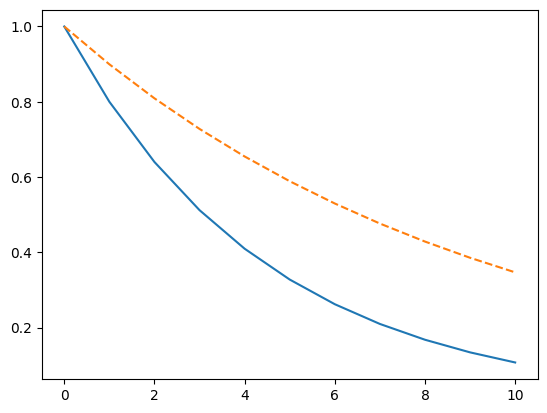

In [8]:
import matplotlib.pyplot as plt

plt.plot(y_true)
plt.plot(y_pred, "--")
plt.show()